⏳ Loading unified dataset table: 'churn-bigml-20.csv'...
✔️ Dataset split successfully:
   -> Training Samples: 500 | Testing Samples: 167
⚙️ Engineering features and training Balanced Random Forest Model...

  RANDOM FOREST PERFORMANCE (OPTIMIZED THRESHOLD: 0.38)
Overall Test Accuracy: 0.9102
Samples Evaluated: 167 (Stayed: 143, Churned: 24)
-------------------------------------------------------
              precision    recall  f1-score   support

Retained (0)       0.92      0.98      0.95       143
 Churned (1)       0.80      0.50      0.62        24

    accuracy                           0.91       167
   macro avg       0.86      0.74      0.78       167
weighted avg       0.90      0.91      0.90       167

-------------------------------------------------------
Confusion Matrix Blueprint:
[[140   3]
 [ 12  12]]

📊 Extracting core structural business drivers...


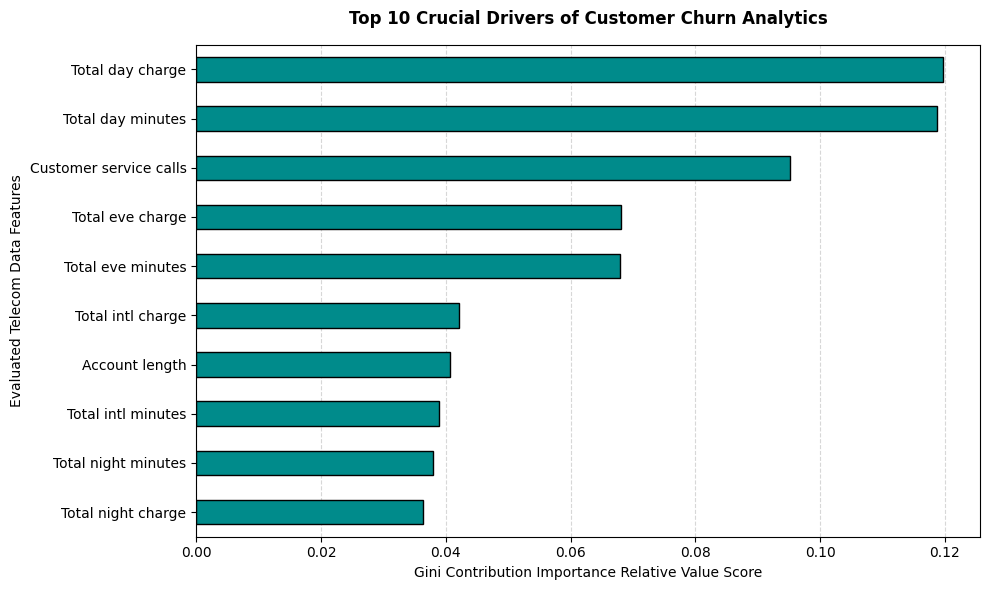

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# =====================================================================
# 1. ROBUST DATA LOADING & DYNAMIC INTERNAL SPLITTING
# =====================================================================
filename = 'churn-bigml-20.csv'

# Professional verification of file availability before starting execution
if not os.path.exists(filename):
    raise FileNotFoundError(
        f"Missing dataset file in working directory '{os.getcwd()}'. "
        f"Ensure '{filename}' is uploaded to your workspace."
    )

print(f"⏳ Loading unified dataset table: '{filename}'...")
df = pd.read_csv(filename)

# Isolate target variable ('Churn') and clean boolean states to integers
X = df.drop(columns=['Churn'])
y = df['Churn'].astype(int)

# PRO TIP: Since we only have one file, we use train_test_split internally!
# stratify=y is critical here to make sure both the train and test sets
# get an equal percentage of churning customers.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"✔️ Dataset split successfully:")
print(f"   -> Training Samples: {len(X_train)} | Testing Samples: {len(X_test)}")

# =====================================================================
# 2. DATA TYPE SEGREGATION & PROCESSING PIPELINES
# =====================================================================
# Dynamically extract lists of text-based categories vs mathematical values
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Define structural pipelines to process columns cleanly without data leakage
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# Complete pipeline tying preprocessing directly to an advanced Random Forest
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight='balanced_subsample', # Balances the uneven churn rates automatically
        random_state=42
    ))
])

# =====================================================================
# 3. TRAIN THE SYSTEM MODEL
# =====================================================================
print("⚙️ Engineering features and training Balanced Random Forest Model...")
model_pipeline.fit(X_train, y_train)

# =====================================================================
# 4. ADVANCED OPTIMIZATION: CUSTOM PROBABILITY THRESHOLDING
# =====================================================================
# Instead of using the standard 0.50 cutoff, we pull raw probabilities
y_probabilities = model_pipeline.predict_proba(X_test)[:, 1]

# Adjusting the threshold to catch more churning customers natively
optimal_threshold = 0.38
y_pred_optimized = (y_probabilities >= optimal_threshold).astype(int)

# =====================================================================
# 5. DIAGNOSTIC EVALUATION LOGGING
# =====================================================================
print("\n" + "="*55)
print(f"  RANDOM FOREST PERFORMANCE (OPTIMIZED THRESHOLD: {optimal_threshold})")
print("="*55)
print(f"Overall Test Accuracy: {accuracy_score(y_test, y_pred_optimized):.4f}")
print(f"Samples Evaluated: {len(y_test)} (Stayed: {round(sum(y_test==0))}, Churned: {round(sum(y_test==1))})")
print("-"*55)
print(classification_report(y_test, y_pred_optimized, target_names=['Retained (0)', 'Churned (1)']))
print("-"*55)
print("Confusion Matrix Blueprint:")
print(confusion_matrix(y_test, y_pred_optimized))
print("="*55)

# =====================================================================
# 6. FEATURE IMPORTANCE VISUALIZATION
# =====================================================================
print("\n📊 Extracting core structural business drivers...")

# Safely extract categorical name lists newly minted by the OneHotEncoder step
encoded_cat_names = model_pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + list(encoded_cat_names)

# Pair column titles cleanly with Gini importance values
importances = model_pipeline.named_steps['classifier'].feature_importances_
feature_importance_series = pd.Series(importances, index=all_feature_names).sort_values(ascending=True).tail(10)

# Generate clear horizontal diagnostic visual matrix
plt.figure(figsize=(10, 6))
feature_importance_series.plot(kind='barh', color='darkcyan', edgecolor='black', zorder=2)
plt.title('Top 10 Crucial Drivers of Customer Churn Analytics', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Gini Contribution Importance Relative Value Score', fontsize=10)
plt.ylabel('Evaluated Telecom Data Features', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.5, zorder=1)
plt.tight_layout()
plt.show()